In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("/Users/kelly/Downloads/goemotions/data/train.tsv", sep="\t", header=None)
df.columns = ["text", "labels", "id"] if df.shape[1] == 3 else ["text", "labels"]

df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [21]:
#Basic Dataset overview

print("Samples:", df.shape[0])
print("Columns:", df.shape[1])
df.info()

Samples: 43410
Columns: 3
<class 'pandas.DataFrame'>
RangeIndex: 43410 entries, 0 to 43409
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    43410 non-null  str  
 1   labels  43410 non-null  str  
 2   id      43410 non-null  str  
dtypes: str(3)
memory usage: 1017.6 KB


In [22]:
#Number of unique labels

df["labels"] = df["labels"].apply(lambda x: list(map(int, x.split(","))))

In [23]:
#Label mapping

label_names = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement",
    "fear", "gratitude", "grief", "joy", "love", "nervousness",
    "optimism", "pride", "realization", "relief", "remorse",
    "sadness", "surprise", "neutral"
]

In [24]:
#Combining multi-labels

from collections import Counter

all_labels = []

for row in df["labels"]:
    all_labels.extend(row)

label_counts = Counter(all_labels)

label_dist = pd.DataFrame({
    "label": [label_names[i] for i in label_counts.keys()],
    "count": list(label_counts.values())
}).sort_values("count", ascending=False)

label_dist

,label,count
0,neutral,14219
8,admiration,4130
11,approval,2939
5,gratitude,2662
3,annoyance,2470
10,amusement,2328
18,curiosity,2191
20,love,2086
22,disapproval,2022
7,optimism,1581


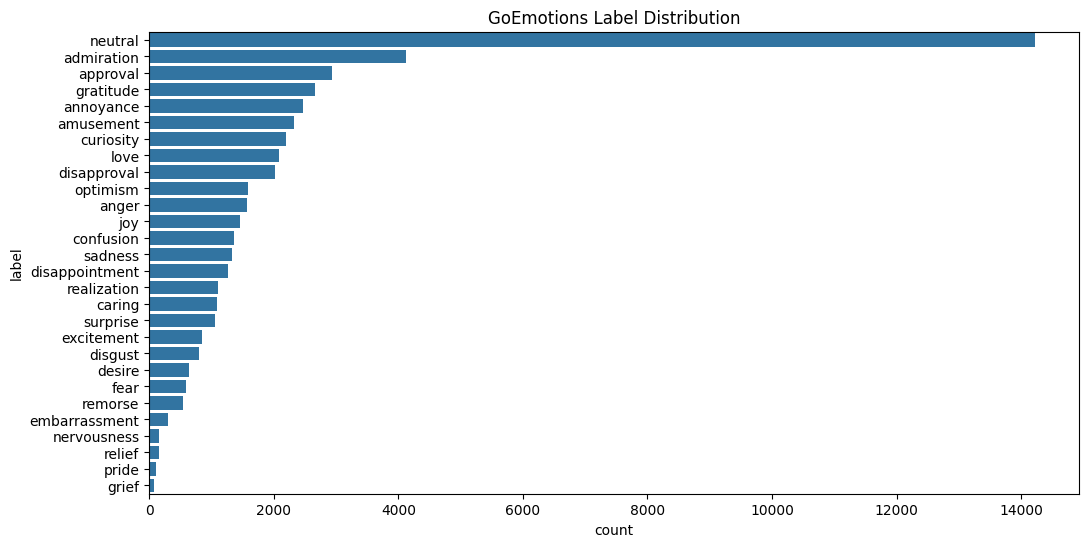

In [25]:
#Plotting distribution

plt.figure(figsize=(12,6))
sns.barplot(data=label_dist, x="count", y="label")
plt.title("GoEmotions Label Distribution")
plt.show()

In [26]:
#Checking class imbalances

label_dist.tail(10)

,label,count
21,excitement,853
24,disgust,793
6,desire,641
2,fear,596
23,remorse,545
13,embarrassment,303
27,nervousness,164
25,relief,153
26,pride,111
16,grief,77


In [27]:
#Checking text length distribution

df["text_length"] = df["text"].apply(len)

In [28]:
#Summary stats

df["text_length"].describe()

count    43410.000000
mean        68.400875
std         36.721898
min          2.000000
25%         38.000000
50%         65.000000
75%         96.000000
max        703.000000
Name: text_length, dtype: float64

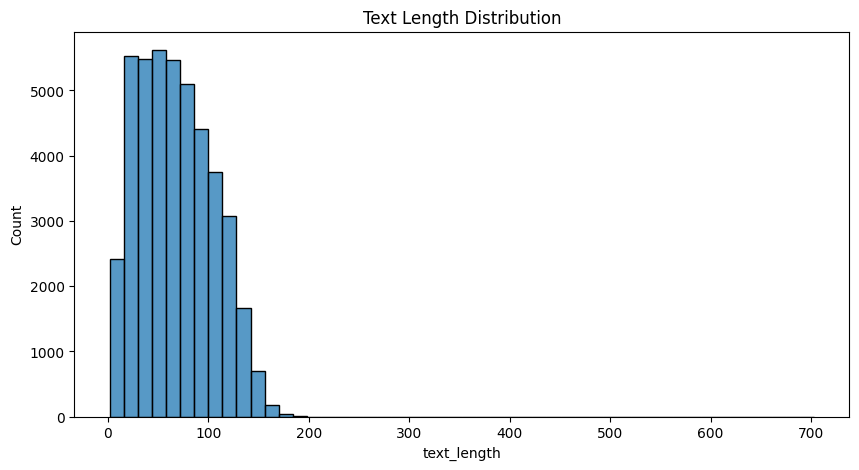

In [29]:
#Plotting text length distribution

plt.figure(figsize=(10,5))
sns.histplot(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

In [30]:
# 27 GoEmotions labels → 6 TextMe mood classes

GOEMOTIONS_TO_TEXTME = {
    "joy": "positive",
    "amusement": "positive",
    "excitement": "positive",
    "gratitude": "positive",
    "love": "positive",
    "optimism": "positive",
    "pride": "positive",
    "relief": "positive",
    "admiration": "positive",
    "approval": "positive",
    "caring": "positive",

    "sadness": "sad",
    "grief": "sad",
    "disappointment": "sad",
    "remorse": "sad",
    "embarrassment": "sad",

    "anger": "angry",
    "annoyance": "angry",
    "disapproval": "angry",
    "disgust": "angry",

    "fear": "fear",
    "nervousness": "fear",

    "confusion": "neutral",
    "curiosity": "neutral",
    "realization": "neutral",
    "surprise": "neutral",
    "neutral": "neutral",

    "desire": "neutral"
}

In [31]:
def map_to_textme(emotion_indices, label_names):
    """
    Convert GoEmotions label indices → TextMe mood class
    """

    mapped = [
        GOEMOTIONS_TO_TEXTME[label_names[i]]
        for i in emotion_indices
        if label_names[i] in GOEMOTIONS_TO_TEXTME
    ]

    if len(mapped) == 0:
        return "neutral"

    # majority vote for multi-label cases
    return max(set(mapped), key=mapped.count)

In [32]:
df["mood"] = df["labels"].apply(lambda x: map_to_textme(x, label_names))

df["mood"].value_counts()

mood
neutral     19615
positive    14819
angry        5634
sad          2625
fear          717
Name: count, dtype: int64